In [35]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.load('tiny_nerf_data.npz')

In [3]:
type(data)

numpy.lib.npyio.NpzFile

In [4]:
list(data.keys())

['images', 'poses', 'focal']

In [9]:
for k in data.keys():
    print(f'{k} : {data[k].shape}')

images : (106, 100, 100, 3)
poses : (106, 4, 4)
focal : ()


In [11]:
focal = data['focal'] # 카메라의 (초점) 거리
focal

array(138.8888789)

In [15]:
images = data['images']
images.max().item(), images.min().item()

(1.0, 0.0)

In [22]:
poses = data['poses']
print(poses.shape)
print(poses[0])

(106, 4, 4)
[[-9.9990219e-01  4.1922452e-03 -1.3345719e-02 -5.3798322e-02]
 [-1.3988681e-02 -2.9965907e-01  9.5394367e-01  3.8454704e+00]
 [-4.6566129e-10  9.5403719e-01  2.9968831e-01  1.2080823e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]


In [ ]:
images.shape # (106, 100, 100, 3)

(106, 100, 100, 3)

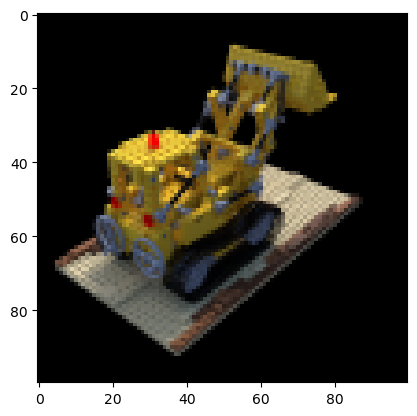

In [93]:
plt.imshow(images[34])

In [ ]:
H, W = images.shape[1:3]


In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# torch.set_default_dtype(torch.float32) # 기본 자료형을 torch.float32(디폴트임)로 고정
L_embed = 6 # 입력 차원 변경
# 원래 기본 입력차원 위치 x,y,z 방향(a,b,c)
# 위치 --> 기본 입력값 x 6 x 2(sin,cos) = 36
# 총 입력 차원 : 39 (실제 논문에서는 위치와 방향이 따로 들어감)

In [36]:
class NeRF(nn.Module):
    def __init__(self,filter_size=128,L_embed=6):
        self.layer1 = nn.Linear(3+ 3*2*L_embed, filter_size) # 3(방향) + 3(위치)x2(sin,cos)xL_embed
        self.layer2 = nn.Linear(filter_size,filter_size)
        self.layer3 = nn.Linear(filter_size, 4) # r,g,b,d(밀도)
        self.relu = nn.ReLU()
    
    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x) # 나중에 rgb는 sigmoid, 밀도는 relu
        return x

In [63]:
def posenc(x,L_embed): # 2d tensor (n x 3) --> 2d tensor (n x (2(sin,cos)xL_embed+1)x기본위치)))
    rets = [x]
    for i in range(L_embed):
        for fn in [torch.sin, torch.cos]:
            rets.append(fn(x * 2.0**i))
    # 0,1 중에서 1dim으로 붙이겠다.
    return torch.cat(rets, dim=-1) # torch.cat은 합치는 차원 외에는 크기가 같아야 함

In [64]:
_ = posenc(torch.tensor([[1,2,3],[4,5,6]]),6)

In [68]:
_.shape

torch.Size([2, 39])

In [69]:
embed_fn = posenc

In [108]:
tensor1 = torch.tensor([1,2,3])
tensor2 = torch.tensor([4,5,6])
tensor3 = torch.tensor([7,8,9])
i,j = torch.meshgrid(tensor1,tensor2,indexing='xy')
j.transpose(1,0)
# i,j = torch.meshgrid(tensor1,tensor2,indexing='xy')
# j

tensor([[4, 5, 6],
        [4, 5, 6],
        [4, 5, 6]])

In [106]:
torch.ones_like(tensor1)

tensor([1, 1, 1])

In [116]:
tensor4 = torch.tensor([
    [1,2,3],
    [6,5,4],
    [7,8,9],
])
tensor4

tensor([[1, 2, 3],
        [6, 5, 4],
        [7, 8, 9]])

In [117]:
tensor1[None,:].shape

torch.Size([1, 3])

In [119]:
tensor4[:2,-1]

tensor([3, 4])

In [118]:
torch.sum(tensor4,dim=-1)

tensor([ 6, 15, 24])

In [113]:
tensor1[None,:] * tensor4

tensor([[ 1,  4,  9],
        [ 6, 10, 12],
        [ 7, 16, 27]])

In [121]:
torch.rand([100,100,64]).shape

torch.Size([100, 100, 64])

In [ ]:
def get_rays(H,W,focal,c2w):    
    x,y = torch.meshgrid(torch.arange(W),torch.arange(H),indexing='xy')
    
    dirs = torch.stack([(x-W*0.5)/focal , (y-H*0.5)/focal] , torch.ones_like(x),dim=-1).to(device)

    rays_d = torch.sum(dirs[...,None,:] * c2w[:3,:3], dim=-1) # 행렬 계산과 같음 @는 여기서 바로 사용이 어렵기 때문에
    # w, h, 3(x,y,z)
    rays_o = c2w[:3,-1].expand(rays_d.shape)
    return rays_o, rays_d

def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):
    def batchify(fn, chunk=1024*32):
        return lambda inputs : torch.cat([fn(inputs[i:i+chunk]) for i in range(0,inputs.shape[0],chunk)],dim=0)
    
    def exclusive_cuprod(tensor):
        cumprod = torch.cumprod(tensor, dim=-1)
        cumprod = torch.roll(cumprod, 1, dims=-1)
        cumprod[..., 0] = 1.0
        return cumprod
    
    z_vals = torch.linspace(near, far, N_samples).to(device) # 1d tensor
    if rand:
        z_vals = z_vals + torch.rand(list(rays_o.shape[:-1])+[N_samples]).to(device)*(far-near)/N_samples
        # 1d --> (100,100,64)
    pts = rays_o[...,None,:] + rays_d[...,None,:]*z_vals[...,:,None] # --> (100,100,64,3)
    # rays_o (100,100,1,3)
    # rays_d (100,100,1,3)
    # z_vals (100,100,64,1) or (64,1)

    pts_flat = torch.reshape(pts,[-1,3])
    pts_flat = embed_fn(pts_flat,L_embed)
    raw = batchify(network_fn)(pts_flat) # 100*100*64*4
    raw = torch.reshape(raw,list(pts.shape[:-1])+[4])

    sigma_a = nn.functional.relu(raw[...,3])
    rgb = torch.sigmoid(raw[...,:3])
    dists = torch.cat([z_vals[...,1:] - z_vals[...,:-1],
                       torch.ten])
